# 1 - Signal exploration

What the MIT-BIH data actually looks like, and what the preprocessing does to it.

All logic lives in `src/ecg`; this notebook only calls it and plots.

**Prerequisite:** `python scripts/download_data.py && python scripts/build_csv.py`

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np

from ecg.config import CLASSES, DS1, DS2, Config
from ecg.data import load_record
from ecg.preprocessing import denoise
from ecg.segmentation import segment_record
from ecg.viz import plot_beats, plot_class_balance

cfg = Config(interim_dir="../data/interim")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## The raw signal

Record 213 -- 30 minutes, 360 Hz, two leads. We use MLII throughout.

In [2]:
record = load_record(213, Config(interim_dir="../data/interim", denoise=None))
print(record)
print(f"duration: {record.n_samples / cfg.sampling_rate / 60:.1f} minutes")

Record(213, 650000 samples, leads=['MLII', 'V1'], 3294 annotations)
duration: 30.1 minutes


## What denoising does

Three strategies are available. The default is FIR: baseline wander is estimated
with two median filters (200 ms and 600 ms) and subtracted, then a 35 Hz low-pass
FIR removes high-frequency noise.

Note the FIR path is *causal* (`lfilter`), so it introduces a small phase shift.
That is deliberate -- it matches the original implementation.

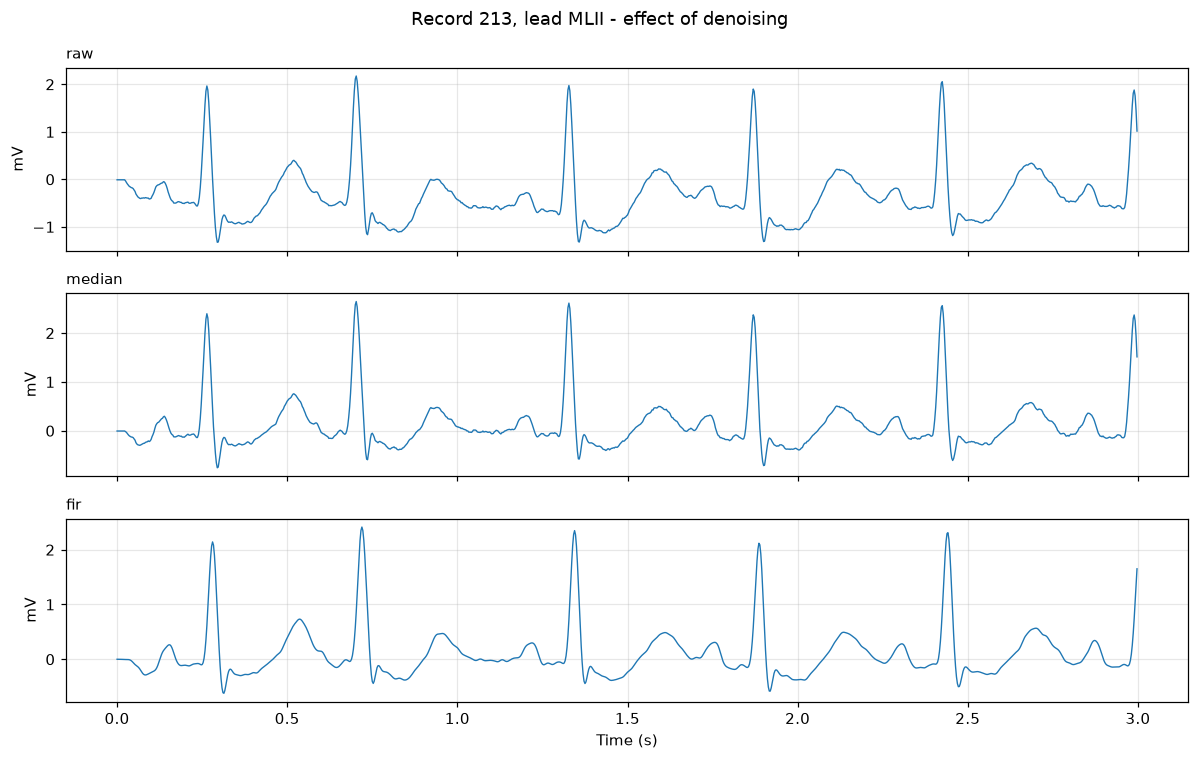

In [3]:
window = slice(0, 3 * cfg.sampling_rate)   # first 3 seconds
time_s = np.arange(window.stop) / cfg.sampling_rate

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, method in zip(axes, ["raw", "median", "fir"]):
    signal = (record.signal if method == "raw"
              else denoise(record.signal, cfg, method=method))
    ax.plot(time_s, signal["MLII"].to_numpy()[window], linewidth=0.9)
    ax.set_ylabel("mV")
    ax.set_title(method, loc="left", fontsize=10)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Record 213, lead MLII - effect of denoising", fontsize=12)
fig.tight_layout()

## Beat segmentation

Each beat is a fixed 151-sample window centred on the annotated R-peak:
50 samples before, 100 after. At 360 Hz that is 419 ms.

Beats whose neighbours sit too close for the window to fit are dropped rather
than padded.

In [4]:
beats = segment_record(load_record(213, cfg), cfg)
print(f"{len(beats):,} usable beats")
print(f"window: {cfg.window_length} samples = {cfg.window_ms:.0f} ms")
beats[["Patient", "Sample", "Label", "Length left", "Heart rate"]].head()

3,225 usable beats
window: 151 samples = 419 ms


,Patient,Sample,Label,Length left,Heart rate
0,213,95,N,76,284.210526
1,213,253,N,157,137.579618
2,213,478,N,224,96.428571
3,213,673,N,194,111.340206
4,213,873,N,199,108.542714


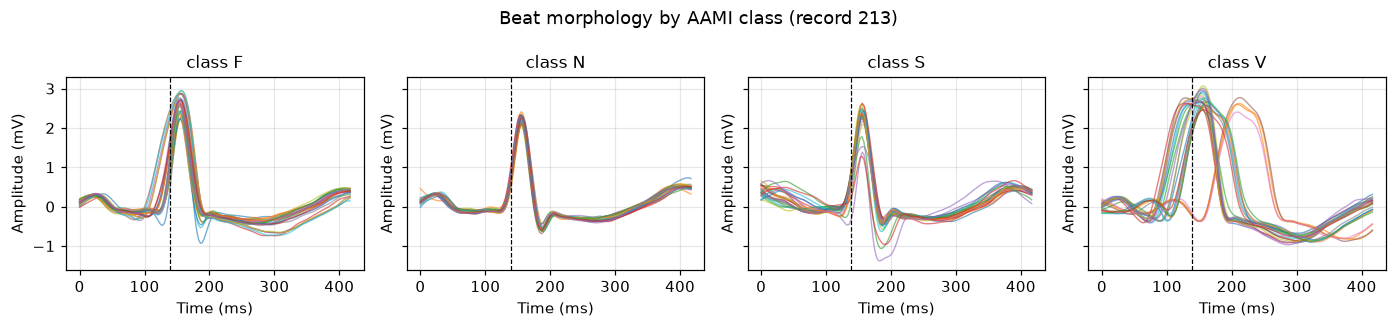

In [5]:
present = [c for c in CLASSES if (beats["Label"] == c).any()]
fig, axes = plt.subplots(1, len(present), figsize=(3.2 * len(present), 3), sharey=True)
for ax, label in zip(np.atleast_1d(axes), present):
    plot_beats(beats, label=label, n=25, ax=ax, cfg=cfg)
    ax.set_title(f"class {label}", fontsize=11)
    ax.get_legend().remove()
fig.suptitle("Beat morphology by AAMI class (record 213)", fontsize=12)
fig.tight_layout()

## Class imbalance

This is the central difficulty. Class N dominates; class F is well under 1%.

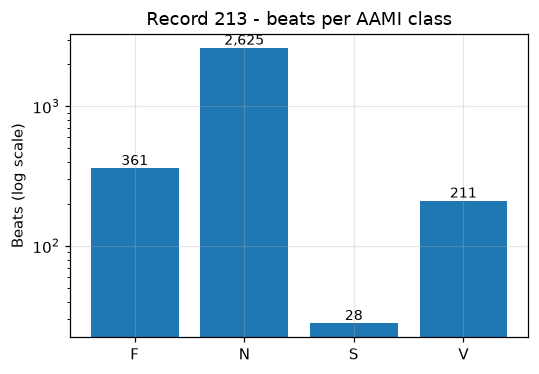

In [6]:
ax = plot_class_balance(beats)
ax.set_title("Record 213 - beats per AAMI class")
plt.tight_layout()

## The DS1 / DS2 split

The de Chazal *et al.* division. The global model trains on DS1 and is evaluated
on DS2; **no patient appears in both**.

In [7]:
print(f"DS1 ({len(DS1)} records, global training): {list(DS1)}")
print(f"DS2 ({len(DS2)} records, evaluation):      {list(DS2)}")
assert not set(DS1) & set(DS2), "DS1 and DS2 must be disjoint"
print("\ndisjoint: confirmed")

DS1 (22 records, global training): [101, 106, 108, 109, 112, 114, 115, 116, 118, 119, 122, 124, 201, 203, 205, 207, 208, 209, 215, 220, 223, 230]
DS2 (22 records, evaluation):      [100, 103, 105, 111, 113, 117, 121, 123, 200, 202, 210, 212, 213, 214, 219, 221, 222, 228, 231, 232, 233, 234]

disjoint: confirmed
